<a href="https://colab.research.google.com/github/herdinsavira/AI/blob/main/JOBSHEET_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Persiapan & Import Library**

In [1]:
# Import library utama
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting tampilan plot
sns.set(style='whitegrid')

**2. Pertanyaan BIsnis**



    *   Bagimana pola penyewaan sepeda berdasarkan jam dalam sehari? Pada jam berapa mencapai puncaknya?
    *   Bagaimana pengaruh kondisi cuaca terhadap total jumlah penyewaan sepeda harian?



**3. Data Wrangling (Load & Quick)**

Sebelum melakukan EDA, kita muat dataset hour.csv atau day.csv (dari Bike Sharing Dataset).

In [3]:
# Memuat data
# Pastikan file 'day.csv' dan 'hour.csv' sudah diunggah ke Colab
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

# Menampilkan 5 baris pertama
print("--- Data Harian ---")
display(day_df.head())

# Memeriksa informasi tipe data dan missing values
print("\n--- Info Data Harian ---")
day_df.info()

--- Data Harian ---


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



--- Info Data Harian ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB



**4. Exploratory Data Analysis (EDA)**

1. Eksplorasi Data Penyewaan Berdasarkan Jam (Menjawab Pertanyaan 1)

menggunakan pivot table pada hour_df untuk melihat rata-rata penyewaan sepeda per jam.

In [4]:
# Pivot Table: Rata-rata penyewaan berdasarkan jam (hr)
hourly_rentals = hour_df.groupby('hr').agg({
    'cnt': ['mean', 'max', 'min']
}).reset_index()

# Merapikan nama kolom
hourly_rentals.columns = ['hour', 'avg_cnt', 'max_cnt', 'min_cnt']
display(hourly_rentals.head(10))

,hour,avg_cnt,max_cnt,min_cnt
0,0,53.898072,283,2
1,1,33.375691,168,1
2,2,22.869930,132,1
3,3,11.727403,79,1
4,4,6.352941,28,1
5,5,19.889819,66,1
6,6,76.044138,213,1
7,7,212.064649,596,1
8,8,359.011004,839,5
9,9,219.309491,426,14


**jumlah penyewaan (cnt) melonjak tajam pada jam-jam sibuk berangkat dan pulang kerja (sekitar jam 08.00 pagi dan 17.00 - 18.00 sore).

2. Eksplorasi Data Penyewaan Berdasarkan Cuaca (Menjawab Pertanyaan 2)

menggunakan pivot table pada day_df untuk menganalisis dampaknya berdasarkan kategori cuaca (weathersit).

In [5]:
# Mapping keterangan cuaca agar lebih mudah dipahami
# 1: Cerah/Berawan Tipis, 2: Mendung/Kabut, 3: Hujan Ringan/Salju Ringan, 4: Hujan Lebat/Badai
weather_labels = {
    1: 'Cerah / Berawan',
    2: 'Mendung / Berkabut',
    3: 'Hujan Ringan / Salju',
    4: 'Cuaca Ekstrem'
}
day_df['weather_label'] = day_df['weathersit'].map(weather_labels)

# Pivot Table: Total & Rata-rata penyewaan berdasarkan cuaca
weather_rentals = day_df.groupby('weather_label').agg({
    'cnt': ['count', 'mean', 'sum']
}).reset_index()

weather_rentals.columns = ['Kondisi Cuaca', 'Jumlah Hari', 'Rata-rata Penyewaan', 'Total Penyewaan']
display(weather_rentals)

,Kondisi Cuaca,Jumlah Hari,Rata-rata Penyewaan,Total Penyewaan
0,Cerah / Berawan,463,4876.786177,2257952
1,Hujan Ringan / Salju,21,1803.285714,37869
2,Mendung / Berkabut,247,4035.862348,996858


**Tingkat penyewaan paling tinggi terjadi saat cuaca Cerah / Berawan, dan menurun drastis saat terjadi Hujan / Salju.

**5. Visualisasi Data**



Visualisasi 1: Tren Penyewaan Sepeda Per Jam

/tmp/ipykernel_1678/1786583522.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


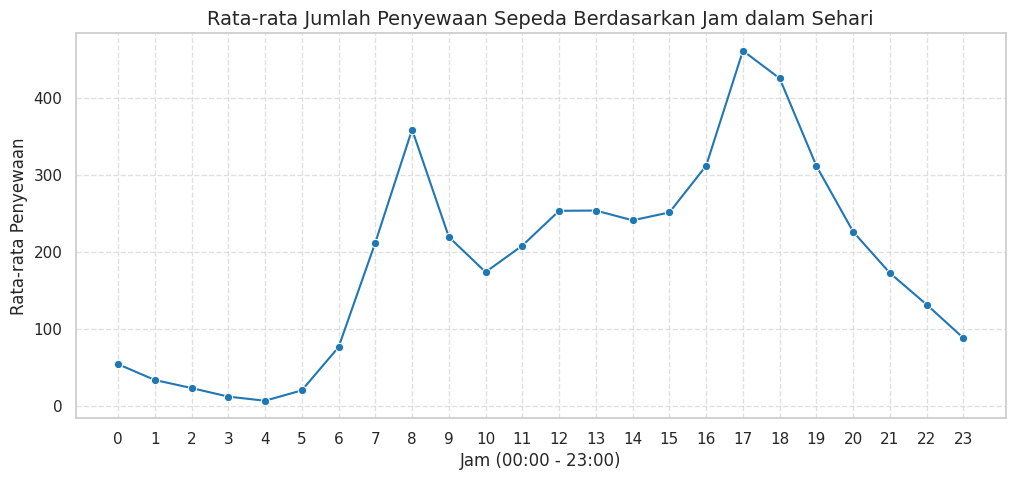

In [7]:
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=hour_df,
    x='hr',
    y='cnt',
    estimator='mean',
    ci=None,
    marker='o',
    color='tab:blue'
)

plt.title('Rata-rata Jumlah Penyewaan Sepeda Berdasarkan Jam dalam Sehari', fontsize=14)
plt.xlabel('Jam (00:00 - 23:00)', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Visualisasi 2: Pengaruh Cuaca Terhadap Penyewaan Sepeda

/tmp/ipykernel_1678/590799673.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1678/590799673.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


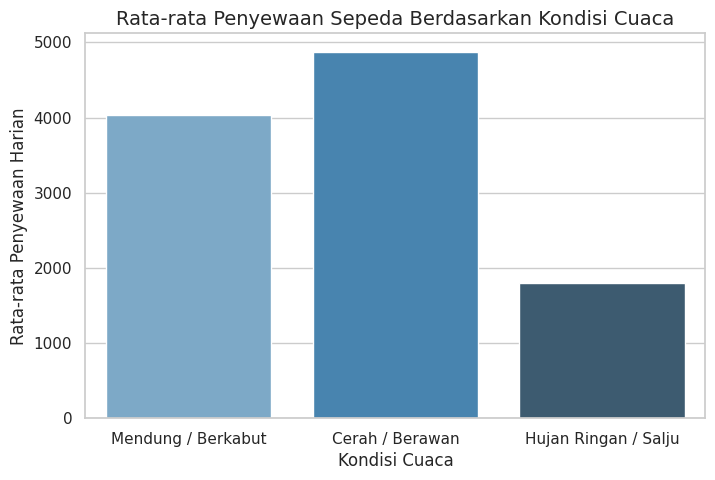

In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=day_df,
    x='weather_label',
    y='cnt',
    estimator=np.mean,
    ci=None,
    palette='Blues_d'
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca', fontsize=14)
plt.xlabel('Kondisi Cuaca', fontsize=12)
plt.ylabel('Rata-rata Penyewaan Harian', fontsize=12)
plt.show()

6. Kesimpulan



    *   Pola penyewaan sepeda harian memiliki dua puncak utama, ysitu pada pukul 08.00 dan 17.00-18.00. Hal ini mengindikasikan bahwa sebagian besar pengguna memanfaatkan sepeda sebagai saran tarnportasi mobilitas rutin untuk berangkat dan pulang kerja atau sekolah.



    *   Kondisi cuaca berpengaruh seignifikan terhadap jumalah penyewaan sepeda. Tingkat penyewan tertinggi terjadi saat cuaca cerah / berawan. Sebaliknya, ketika cuaca memburuk menjadi hujan / salju, penyewaan mengalami penurunan drastis karena faktor kenyamanan dan keselamatan pengguna.

